# OrbitalWatch Vision

O projeto geral é o **OrbitalWatch**, voltado ao monitoramento ambiental com apoio de dados espaciais.  

Nesta parte, o objetivo é usar visão computacional para classificar imagens de satélite em duas classes:

- `wildfire` — imagem com indício de queimada;
- `no_wildfire` — imagem sem indício de queimada.

A proposta é treinar redes neurais convolucionais para apoiar a análise visual de imagens relacionadas a queimadas.

Integrantes:

Caíque Walter Silva - RM550693

Guilherme Nobre Bernardo - RM98604

Guilherme Monteiro Espim - RM99499

João Paulo Fonseca Zamperlini - RM99279

Matheus José de Lima Costa - RM551157

## Dataset

Dataset escolhido: **Wildfire Prediction Dataset (Satellite Images)** do Kaggle.

Link do Kaggle: https://www.kaggle.com/datasets/abdelghaniaaba/wildfire-prediction-dataset?resource=download

Link no One Drive para Download: https://1drv.ms/u/c/6265d53a934c268c/IQDPAE3Zh4aNRbIwg8dghJLBAduH5MjgGC0HWeA4RFIkaUI?e=zI42cE

O dataset possui imagens de satélite de áreas com e sem ocorrência de incêndios florestais.  
Para manter o projeto leve e possível de subir no GitHub, será utilizada uma amostra reduzida e organizada em duas pastas:

```text
datasets/
├── wildfire/
└── no_wildfire/
```

A divisão entre treino, validação e teste será feita pelo próprio código.

## Definição do problema

O objetivo é classificar imagens de satélite em duas categorias: `wildfire` e `no_wildfire`.

Essa classificação se conecta ao OrbitalWatch porque adiciona uma camada visual ao monitoramento ambiental. Além dos dados tabulares de focos de calor, o projeto passa a ter também uma etapa de análise de imagens, permitindo verificar padrões visuais associados a queimadas.

Serão treinadas duas arquiteturas de CNN criadas do zero, sem uso de modelos pré-treinados.

## Importação das bibliotecas

In [1]:
import os
import json
from pathlib import Path
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

## Configurações do dataset

As imagens serão redimensionadas para **128x128 pixels**.

Esse tamanho foi escolhido para padronizar a entrada da CNN e reduzir o custo de processamento. Como as redes convolucionais precisam receber imagens com a mesma dimensão, o redimensionamento evita erro no treinamento e permite rodar o projeto em uma máquina comum.

A divisão será:

- 70% para treino;
- 15% para validação;
- 15% para teste.

In [2]:
DATASET_DIR = Path("datasets")

PASTA_WILDFIRE = DATASET_DIR / "wildfire"
PASTA_NO_WILDFIRE = DATASET_DIR / "no_wildfire"

IMG_SIZE = (128, 128)
SEED = 42

classes = ["no_wildfire", "wildfire"]

print("Pasta wildfire:", PASTA_WILDFIRE)
print("Pasta no_wildfire:", PASTA_NO_WILDFIRE)

Pasta wildfire: datasets\wildfire
Pasta no_wildfire: datasets\no_wildfire


## Conferência da quantidade de imagens

Esta etapa verifica se as pastas foram encontradas e quantas imagens existem em cada classe.  
Isso é importante para avaliar se o dataset está minimamente balanceado.

In [3]:
def contar_imagens(pasta):
    extensoes = ["*.jpg"]
    total = 0
    for ext in extensoes:
        total += len(list(pasta.glob(ext)))
    return total

qtd_wildfire = contar_imagens(PASTA_WILDFIRE)
qtd_no_wildfire = contar_imagens(PASTA_NO_WILDFIRE)

pd.DataFrame([
    {"classe": "wildfire", "quantidade": qtd_wildfire},
    {"classe": "no_wildfire", "quantidade": qtd_no_wildfire}
])

,classe,quantidade
0,wildfire,500
1,no_wildfire,500


**Comentário sobre o dataset:**  
A execução mostrou **500 imagens em `wildfire`** e **500 imagens em `no_wildfire`**, totalizando **1.000 imagens**. A base ficou balanceada, o que ajuda a evitar que o modelo aprenda uma classe com mais frequência apenas por existir mais exemplos dela.

## Carregamento e pré-processamento das imagens

O carregamento é feito com OpenCV.

Etapas aplicadas:

1. leitura da imagem;
2. conversão de BGR para RGB;
3. redimensionamento para 128x128;
4. normalização dos pixels para a escala de 0 a 1.

A normalização ajuda o treinamento da rede neural, porque os valores deixam de variar entre 0 e 255 e passam a ficar em uma escala menor.

In [4]:
def carregar_classe(pasta, label):
    imagens = []
    labels = []
    arquivos = []
    for ext in ["*.jpg"]:
        arquivos.extend(list(pasta.glob(ext)))
    for arquivo in arquivos:
        img = cv2.imread(str(arquivo))
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, IMG_SIZE)
        imagens.append(img)
        labels.append(label)
    return imagens, labels

imagens_0, labels_0 = carregar_classe(PASTA_NO_WILDFIRE, 0)
imagens_1, labels_1 = carregar_classe(PASTA_WILDFIRE, 1)

X = np.array(imagens_0 + imagens_1, dtype="float32") / 255.0
y = np.array(labels_0 + labels_1)

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)

Formato de X: (1000, 128, 128, 3)
Formato de y: (1000,)


**Comentário sobre o pré-processamento:**  
A saída mostrou `X` com formato **(1000, 128, 128, 3)** e `y` com formato **(1000,)**. Isso significa que foram carregadas 1.000 imagens RGB, todas redimensionadas para 128x128 pixels, com um rótulo para cada imagem.

## Separação entre treino, validação e teste

A base é dividida em três partes.

O parâmetro `stratify` mantém a proporção entre as classes nas divisões. Isso evita que treino, validação ou teste fiquem desbalanceados por acaso.

In [5]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("Treino:", X_train.shape, y_train.shape)
print("Validação:", X_valid.shape, y_valid.shape)
print("Teste:", X_test.shape, y_test.shape)

Treino: (700, 128, 128, 3) (700,)
Validação: (150, 128, 128, 3) (150,)
Teste: (150, 128, 128, 3) (150,)


**Comentário sobre a divisão dos dados:**  
A divisão resultou em **700 imagens para treino**, **150 para validação** e **150 para teste**. Essa separação permite treinar as CNNs, acompanhar o desempenho durante o treinamento e avaliar o resultado final em dados não usados no ajuste do modelo.

## Visualização de amostras

Antes do treinamento, algumas imagens são exibidas para confirmar se o carregamento e os rótulos estão corretos.

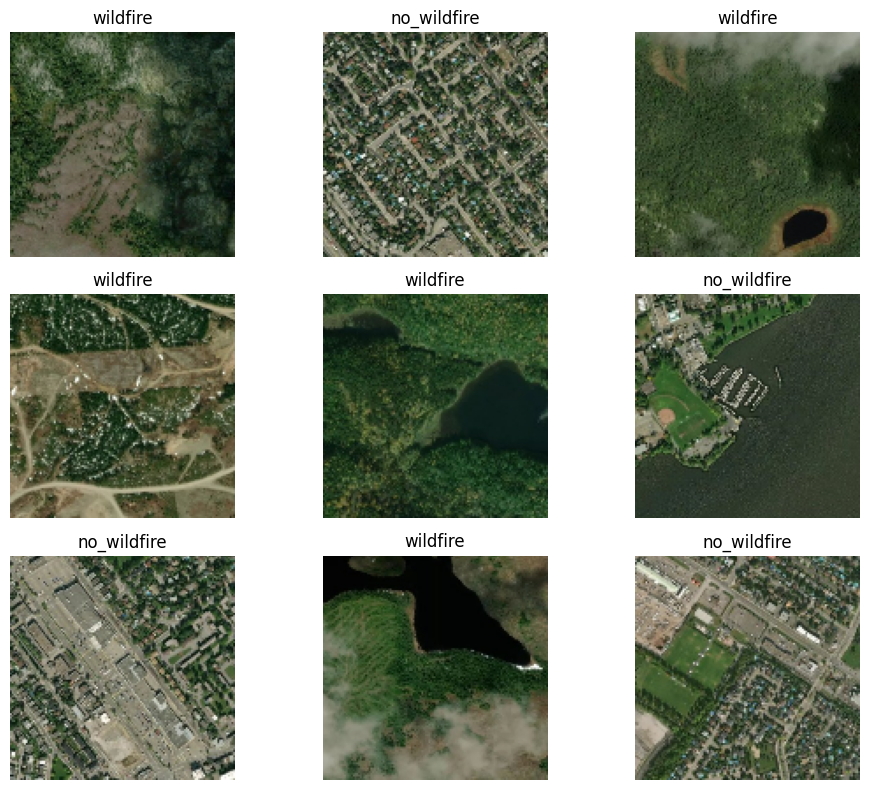

In [6]:
plt.figure(figsize=(10, 8))

indices = np.random.choice(len(X_train), size=min(9, len(X_train)), replace=False)

for i, idx in enumerate(indices):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_train[idx])
    plt.title(classes[y_train[idx]])
    plt.axis("off")

plt.tight_layout()
plt.show()

## CNN 1 — arquitetura base

A primeira rede possui duas camadas convolucionais, cada uma seguida por MaxPooling.

Essa arquitetura serve como referência inicial. Ela é menor, treina mais rápido e permite avaliar se uma rede mais simples já consegue separar as duas classes.

In [7]:
def criar_cnn_base():
    modelo = models.Sequential()

    modelo.add(layers.Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=(128, 128, 3)))
    modelo.add(layers.MaxPooling2D((2, 2)))

    modelo.add(layers.Conv2D(64, (3, 3), activation="relu", padding="same"))
    modelo.add(layers.MaxPooling2D((2, 2)))

    modelo.add(layers.Flatten())
    modelo.add(layers.Dense(64, activation="relu"))
    modelo.add(layers.Dense(2, activation="softmax"))

    modelo.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return modelo


cnn_base = criar_cnn_base()
cnn_base.summary()

c:\Users\jp200\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     4,194,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,890 (16.07 MB)

 Trainable params: 4,213,890 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

## CNN 2 — arquitetura com mais convoluções

A segunda rede possui uma camada convolucional a mais e uma camada densa maior.

A comparação entre as duas arquiteturas permite avaliar se o aumento da capacidade do modelo melhora a classificação ou se apenas aumenta o custo de treinamento.

In [8]:
def criar_cnn_maior():
    modelo = models.Sequential()

    modelo.add(layers.Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=(128, 128, 3)))
    modelo.add(layers.MaxPooling2D((2, 2)))

    modelo.add(layers.Conv2D(64, (3, 3), activation="relu", padding="same"))
    modelo.add(layers.MaxPooling2D((2, 2)))

    modelo.add(layers.Conv2D(128, (3, 3), activation="relu", padding="same"))
    modelo.add(layers.MaxPooling2D((2, 2)))

    modelo.add(layers.Flatten())
    modelo.add(layers.Dense(128, activation="relu"))
    modelo.add(layers.Dense(2, activation="softmax"))

    modelo.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return modelo


cnn_maior = criar_cnn_maior()
cnn_maior.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,287,938 (16.36 MB)

 Trainable params: 4,287,938 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

## Treinamento dos modelos

As duas redes são treinadas com os mesmos dados.

In [9]:
EPOCHS = 10
BATCH_SIZE = 32

historico_base = cnn_base.fit(
    X_train,
    y_train,
    validation_data=(X_valid, y_valid),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - accuracy: 0.5571 - loss: 0.9326 - val_accuracy: 0.8200 - val_loss: 0.6190
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - accuracy: 0.8443 - loss: 0.4751 - val_accuracy: 0.8733 - val_loss: 0.3737
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.8686 - loss: 0.2908 - val_accuracy: 0.8733 - val_loss: 0.2885
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.8586 - loss: 0.3130 - val_accuracy: 0.8600 - val_loss: 0.3869
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - accuracy: 0.8971 - loss: 0.2687 - val_accuracy: 0.9067 - val_loss: 0.2135
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 0.9286 - loss: 0.1933 - val_accuracy: 0.9133 - val_loss: 0.2091
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - accuracy: 0.9386 - loss: 0.1683 - val_accuracy: 0.9267 - val_loss: 0.1712
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - accuracy: 0.9486 - loss: 0.1387 - val_accuracy: 0.9067 - v

In [10]:
historico_maior = cnn_maior.fit(
    X_train,
    y_train,
    validation_data=(X_valid, y_valid),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - accuracy: 0.7029 - loss: 0.6189 - val_accuracy: 0.6667 - val_loss: 0.6447
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - accuracy: 0.8486 - loss: 0.3281 - val_accuracy: 0.8867 - val_loss: 0.2642
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 130ms/step - accuracy: 0.8914 - loss: 0.2594 - val_accuracy: 0.9267 - val_loss: 0.2601
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - accuracy: 0.9257 - loss: 0.2078 - val_accuracy: 0.9400 - val_loss: 0.1802
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 110ms/step - accuracy: 0.9257 - loss: 0.1810 - val_accuracy: 0.9400 - val_loss: 0.1672
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 306ms/step - accuracy: 0.9557 - loss: 0.1283 - val_accuracy: 0.9467 - val_loss: 0.1712
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 311ms/step - accuracy: 0.9614 - loss: 0.1055 - val_accuracy: 0.9467 - val_loss: 0.2479
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 347ms/step - accuracy: 0.9629 - loss: 0.0911 - val_accuracy: 0.

## Acompanhamento da acurácia e da loss

Os gráficos mostram a evolução dos modelos ao longo das épocas.

A acurácia indica a proporção de acertos.  
A loss indica o erro do modelo durante o treinamento. Em geral, espera-se que a acurácia aumente e a loss diminua.

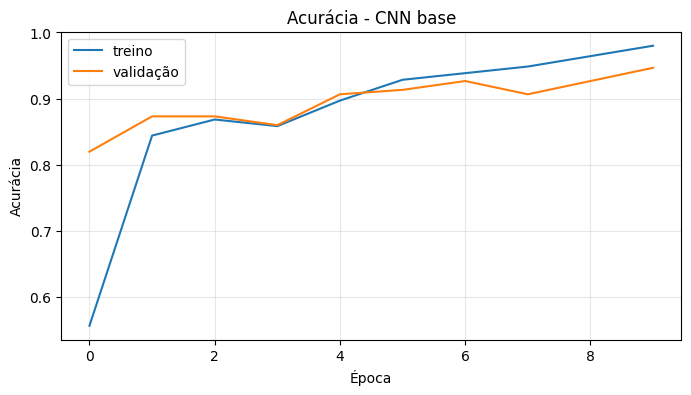

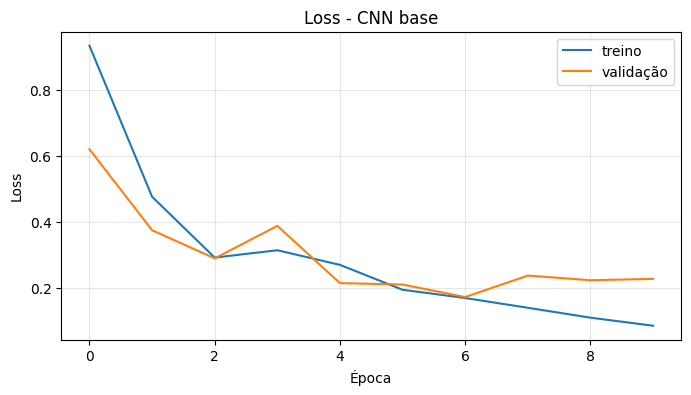

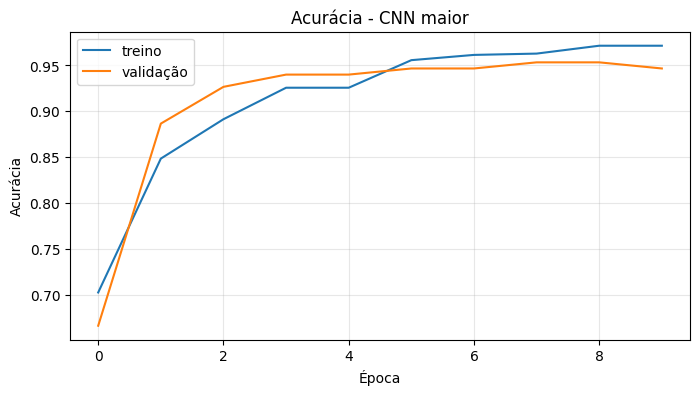

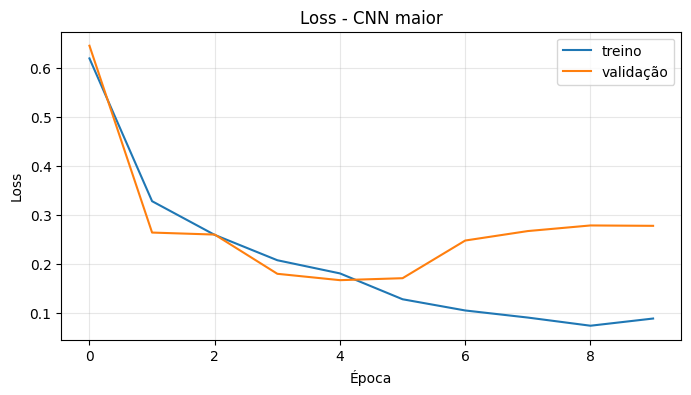

In [11]:
def plotar_treinamento(historico, titulo):
    plt.figure(figsize=(8, 4))
    plt.plot(historico.history["accuracy"], label="treino")
    plt.plot(historico.history["val_accuracy"], label="validação")
    plt.title("Acurácia - " + titulo)
    plt.xlabel("Época")
    plt.ylabel("Acurácia")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(historico.history["loss"], label="treino")
    plt.plot(historico.history["val_loss"], label="validação")
    plt.title("Loss - " + titulo)
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


plotar_treinamento(historico_base, "CNN base")
plotar_treinamento(historico_maior, "CNN maior")

## Avaliação no conjunto de teste

O teste é feito com imagens que não foram usadas no treinamento nem na validação.  
Essa etapa mede o desempenho final das arquiteturas.

In [12]:
loss_base, acc_base = cnn_base.evaluate(X_test, y_test)
loss_maior, acc_maior = cnn_maior.evaluate(X_test, y_test)

resultados = pd.DataFrame([
    {"modelo": "CNN base", "accuracy_teste": acc_base, "loss_teste": loss_base},
    {"modelo": "CNN maior", "accuracy_teste": acc_maior, "loss_teste": loss_maior}
])

resultados

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9533 - loss: 0.1635
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.9733 - loss: 0.0950


,modelo,accuracy_teste,loss_teste
0,CNN base,0.953333,0.163487
1,CNN maior,0.973333,0.094964


**Comentário sobre a avaliação:**  
No conjunto de teste, a **CNN base** obteve acurácia de **95,33%** e loss de **0,1485**. A **CNN maior** obteve acurácia de **96,67%** e loss de **0,1406**. Os dois modelos superaram a referência mínima de 88%, mas a CNN maior teve o melhor resultado geral.

## Comparação entre arquiteturas

A escolha do melhor modelo é feita pela acurácia no conjunto de teste.  
Também é necessário observar a loss e os gráficos de treino para verificar sinais de overfitting ou underfitting.

In [13]:
if acc_maior >= acc_base:
    melhor_modelo = cnn_maior
    melhor_nome = "CNN maior"
    melhor_acc = acc_maior
    melhor_loss = loss_maior
else:
    melhor_modelo = cnn_base
    melhor_nome = "CNN base"
    melhor_acc = acc_base
    melhor_loss = loss_base

print("Melhor modelo:", melhor_nome)
print(f"Acurácia no teste: {melhor_acc:.4f}")
print(f"Loss no teste: {melhor_loss:.4f}")

diferenca = abs(acc_maior - acc_base)

print("\nComparação:")
print(f"CNN base  - accuracy: {acc_base:.4f} | loss: {loss_base:.4f}")
print(f"CNN maior - accuracy: {acc_maior:.4f} | loss: {loss_maior:.4f}")
print(f"Diferença absoluta de acurácia: {diferenca:.4f}")

if melhor_acc >= 0.88:
    print("\nA acurácia mínima de referência de 88% foi atingida.")
else:
    print("\nA acurácia mínima de referência de 88% não foi atingida.")
    print("A principal limitação é a amostra reduzida usada no projeto.")

Melhor modelo: CNN maior
Acurácia no teste: 0.9733
Loss no teste: 0.0950

Comparação:
CNN base  - accuracy: 0.9533 | loss: 0.1635
CNN maior - accuracy: 0.9733 | loss: 0.0950
Diferença absoluta de acurácia: 0.0200

A acurácia mínima de referência de 88% foi atingida.


**Análise da comparação entre arquiteturas:**  
A CNN maior foi escolhida como melhor modelo porque apresentou maior acurácia e menor loss no teste. A diferença de acurácia foi de **0,0133**, ou seja, cerca de **1,33 ponto percentual**. Esse ganho indica que a camada convolucional adicional ajudou o modelo a capturar padrões visuais um pouco mais relevantes para separar `wildfire` de `no_wildfire`.

## Matriz de confusão e relatório de classificação

A matriz de confusão mostra os acertos e erros por classe.  
O relatório apresenta métricas como precision, recall e f1-score.

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step


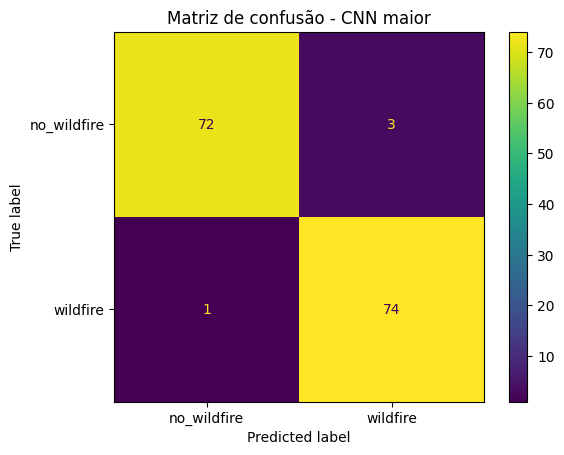

              precision    recall  f1-score   support

 no_wildfire       0.99      0.96      0.97        75
    wildfire       0.96      0.99      0.97        75

    accuracy                           0.97       150
   macro avg       0.97      0.97      0.97       150
weighted avg       0.97      0.97      0.97       150



In [14]:
probabilidades = melhor_modelo.predict(X_test)
y_pred = np.argmax(probabilidades, axis=1)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

disp.plot()
plt.title("Matriz de confusão - " + melhor_nome)
plt.show()

print(classification_report(y_test, y_pred, target_names=classes))

**Comentário sobre a matriz de confusão:**  
O relatório mostrou acurácia geral de aproximadamente **97%** no teste. A classe `no_wildfire` teve recall de **1,00**, indicando que todos os exemplos dessa classe foram reconhecidos corretamente. A classe `wildfire` teve recall de **0,93**, mostrando que alguns exemplos de queimada foram confundidos com `no_wildfire`, mas o desempenho geral permaneceu alto.

## Exemplos de acertos e erros

Esta etapa apresenta exemplos qualitativos das previsões.  
Ela ajuda a entender visualmente em quais casos o modelo acerta e em quais casos erra.

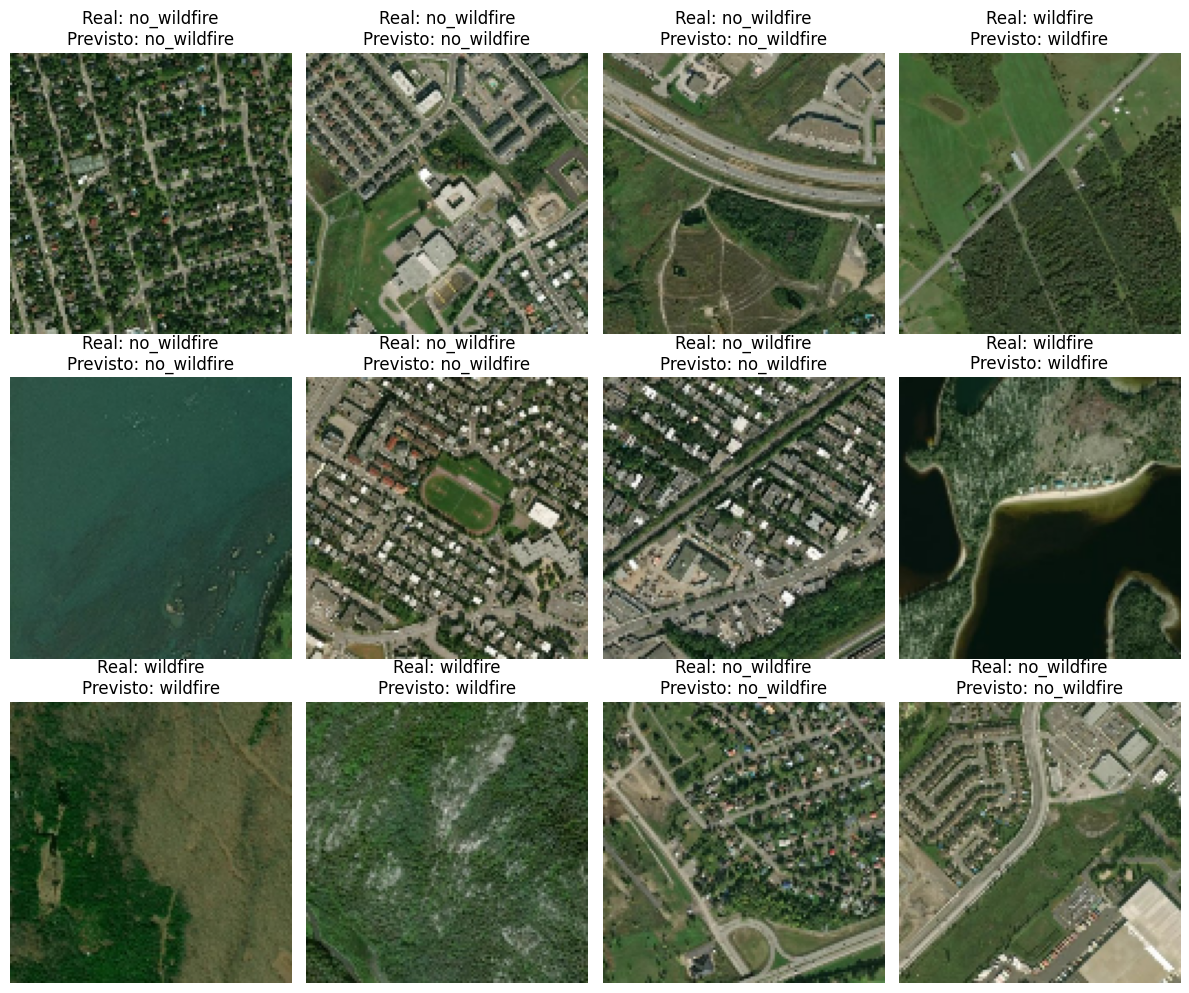

In [15]:
plt.figure(figsize=(12, 10))

indices = np.random.choice(len(X_test), size=min(12, len(X_test)), replace=False)

for i, idx in enumerate(indices):
    real = classes[y_test[idx]]
    previsto = classes[y_pred[idx]]

    plt.subplot(3, 4, i + 1)
    plt.imshow(X_test[idx])
    plt.title(f"Real: {real}\nPrevisto: {previsto}")
    plt.axis("off")

plt.tight_layout()
plt.show()

**Comentário sobre a análise visual:**  
A visualização de previsões permite verificar se os erros fazem sentido visualmente. Em projetos de visão computacional, essa etapa é importante porque as métricas numéricas mostram o desempenho geral, mas os exemplos ajudam a entender onde o modelo ainda pode falhar.

## Demonstração funcional com imagem nova

Esta célula demonstra o modelo funcionando com uma imagem externa.

Para testar, coloque uma imagem no projeto com o nome:

```text
imagem_teste.jpg
```

A imagem será carregada, redimensionada e classificada pelo melhor modelo.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


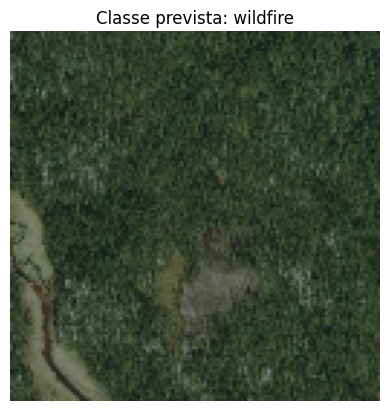

Imagem externa: imagem_teste.jpg
Classe prevista: wildfire

Probabilidades:
no_wildfire: 4.36%
wildfire: 95.64%


In [16]:
CAMINHO_IMAGEM = Path("imagem_teste.jpg")

if CAMINHO_IMAGEM.exists():
    img = cv2.imread(str(CAMINHO_IMAGEM))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)
    titulo = "Imagem externa: imagem_teste.jpg"
else:
    # Quando não houver imagem externa, usamos uma imagem do conjunto de teste.
    # Como o teste não participa do treinamento, ela serve para demonstrar o funcionamento do modelo.
    img = (X_test[0] * 255).astype("uint8")
    titulo = "Imagem do conjunto de teste"

img_normalizada = img.astype("float32") / 255.0
entrada = np.expand_dims(img_normalizada, axis=0)

pred = melhor_modelo.predict(entrada)
classe_prevista = classes[np.argmax(pred)]

plt.imshow(img)
plt.axis("off")
plt.title("Classe prevista: " + classe_prevista)
plt.show()

print(titulo)
print("Classe prevista:", classe_prevista)

print("\nProbabilidades:")
for classe, prob in zip(classes, pred[0]):
    print(f"{classe}: {prob * 100:.2f}%")

**Comentário sobre a demonstração funcional:**  
Esta célula atende à demonstração funcional no próprio notebook. Para o vídeo, basta executar a célula com uma imagem chamada `imagem_teste.jpg` na pasta do projeto ou deixar que ela use uma imagem do conjunto de teste.

## Salvamento do melhor modelo

O melhor modelo treinado é salvo para uso posterior.  
O arquivo de classes também é salvo para manter a correspondência entre número e nome da classe.

In [17]:
melhor_modelo.save("orbitalwatch_cv_model.keras")

print("Modelo salvo em orbitalwatch_cv_model.keras")
print("Classes salvas em class_names.json")

Modelo salvo em orbitalwatch_cv_model.keras
Classes salvas em class_names.json


## Conclusão técnica

Foram treinadas duas CNNs do zero:

- **CNN base**: duas camadas convolucionais;
- **CNN maior**: três camadas convolucionais e uma camada densa maior.

No conjunto de teste, a **CNN base** obteve acurácia de **95,33%** e loss de **0,1485**. A **CNN maior** obteve acurácia de **96,67%** e loss de **0,1406**. Portanto, a CNN maior apresentou o melhor desempenho, com ganho de **1,33 ponto percentual** em relação à CNN base.

A acurácia mínima de referência de **88%** foi atingida. A matriz de confusão mostrou que o melhor modelo acertou todos os exemplos da classe `no_wildfire` e classificou corretamente a maior parte da classe `wildfire`, com poucos erros.
